/tmp/ipykernel_17273/2793552547.py:108: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved → beta_ratio_surface_We_El.png


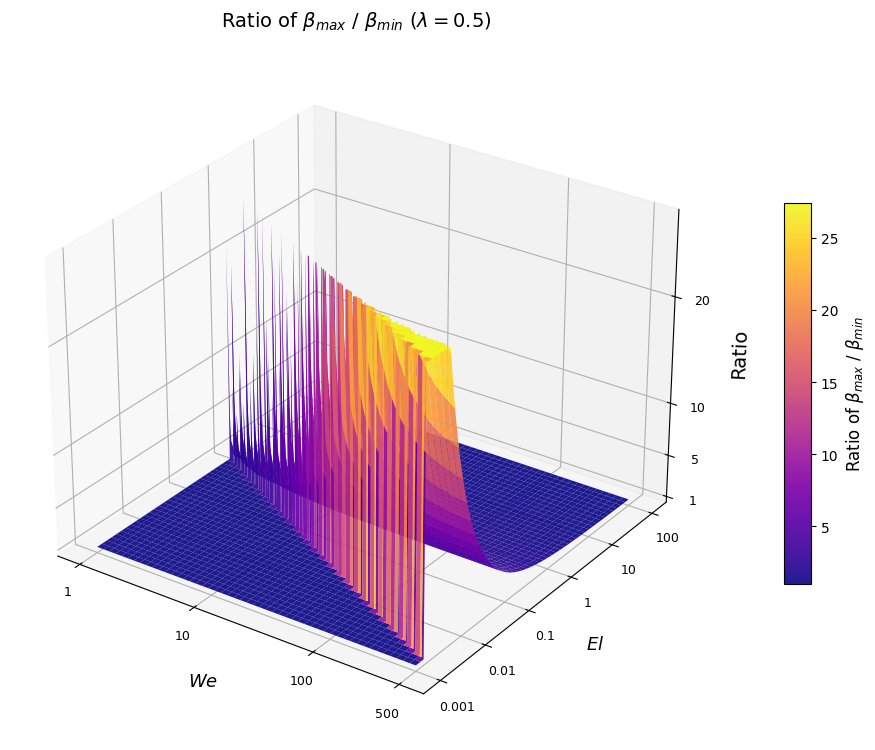

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
import warnings

# ── Tuneable ──────────────────────────────────────
LAMBDA = 0.5          # λ  (set to 1 → (1-λ)=0, simplifies first coefficient)
N_WE   = 500          # grid resolution along We axis
N_EL   = 500          # grid resolution along El axis
# ──────────────────────────────────────────

We_vals = np.logspace(np.log10(1),   np.log10(500), N_WE)   # 1  – 500
El_vals = np.logspace(np.log10(0.001), np.log10(100), N_EL)  # 0.001 – 100

WE, EL = np.meshgrid(We_vals, El_vals)   # shape (N_EL, N_WE)

min_beta_map = np.full(WE.shape, np.nan)
max_beta_map = np.full(WE.shape, np.nan)

for i in range(N_EL):
    for j in range(N_WE):
        we = WE[i, j]
        el = EL[i, j]

        denom1 = 1.0 - 0.75 / (we * el)
        denom2 = 2.0 * we * el - 1.5

        # Skip singular / near-singular points
        if abs(denom1) < 1e-10 or abs(denom2) < 1e-10:
            continue

        A = (1.5 + 0.5 / el * (1.0 - LAMBDA)) / denom1   # coeff of β^4
        B =  4.0 / denom2                                  # coeff of β^3
        C =  0.5 / denom1                                  # constant

        # Polynomial: β^6 - A·β^4 + B·β^3 + 0·β^2 + 0·β + C = 0
        coeffs = [1, 0, -A, B, 0, 0, C]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            roots = np.roots(coeffs)

        # Keep positive real roots (Im small relative to Re)
        pos_real = [
            r.real for r in roots
            if abs(r.imag) < 1e-6 * max(abs(r.real), 1e-12) and r.real > 0
        ]

        if pos_real:
            min_beta_map[i, j] = min(pos_real)   # smallest positive real root
            max_beta_map[i, j] = max(pos_real)   # largest positive real root

# Calculate the ratio of max and min beta values
beta_ratio_map = max_beta_map / min_beta_map

# ── Plotting ──────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

# Mask NaN for clean surface
valid = ~np.isnan(beta_ratio_map)
Z = np.where(valid, beta_ratio_map, np.nan)

# Clip extreme outliers for a readable colour scale
vmin = np.nanpercentile(Z,  2)
vmax = np.nanpercentile(Z, 98)
Z_clipped = np.clip(Z, vmin, vmax)

surf = ax.plot_surface(
    np.log10(WE), np.log10(EL), Z_clipped,
    cmap='plasma',
    linewidth=0, antialiased=True,
    alpha=0.92,
    vmin=vmin, vmax=vmax
)

# Colour bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.55, aspect=14, pad=0.08)
cbar.set_label(r'Ratio of $\beta_{max}$ / $\beta_{min}$', fontsize=12)

# Axis tick labels → original (non-log) values
we_ticks  = [0, 1, 2, np.log10(500)]      # log10 positions
we_labels = ['1', '10', '100', '500']
el_ticks  = [np.log10(0.001), np.log10(0.01), np.log10(0.1), 0, 1, 2]
el_labels = ['0.001', '0.01', '0.1', '1', '10', '100']

ax.set_xticks(we_ticks);  ax.set_xticklabels(we_labels, fontsize=9)
ax.set_yticks(el_ticks);  ax.set_yticklabels(el_labels, fontsize=9)

# Z-axis (Ratio) ticks
z_ticks = np.array([1, 5, 10, 20, 30, 40]) # Include 1 and other reasonable values
z_ticks = z_ticks[z_ticks <= vmax] # Filter ticks that are within vmax range
if 1 not in z_ticks:
    z_ticks = np.insert(z_ticks, 0, 1) # Ensure 1 is always present
ax.set_zticks(z_ticks)
ax.set_zticklabels([str(int(t)) for t in z_ticks], fontsize=9)

ax.set_xlabel(r'$We$',         fontsize=13, labelpad=10)
ax.set_ylabel(r'$El$',         fontsize=13, labelpad=10)
ax.set_zlabel(r'Ratio',      fontsize=14, labelpad=8)
ax.set_title(
    r'Ratio of $\beta_{max}$ / $\beta_{min}$ ($λ = $' + f'{LAMBDA})',
    fontsize=14, pad=15
)

ax.view_init(elev=28, azim=-55)
plt.tight_layout()

out = "beta_ratio_surface_We_El.png"
plt.savefig(out, dpi=180, bbox_inches='tight')
print(f"Saved → {out}")
plt.show()

In [ ]:
np.savetxt('beta_max_map.csv', max_beta_map, delimiter=',')
print('Saved beta_max_map.csv')

Saved beta_max_map.csv


In [ ]:
np.savetxt('beta_min_map.csv', min_beta_map, delimiter=',')
print('Saved beta_min_map.csv')

Saved beta_min_map.csv


In [ ]:
np.savetxt('El_vals.csv', El_vals, delimiter=',')
print('Saved El_vals.csv')

Saved El_vals.csv


In [ ]:
np.savetxt('We_vals.csv', We_vals, delimiter=',')
print('Saved We_vals.csv')

Saved We_vals.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

/tmp/ipykernel_17273/3735280579.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved → min_beta_surface_We_El.png


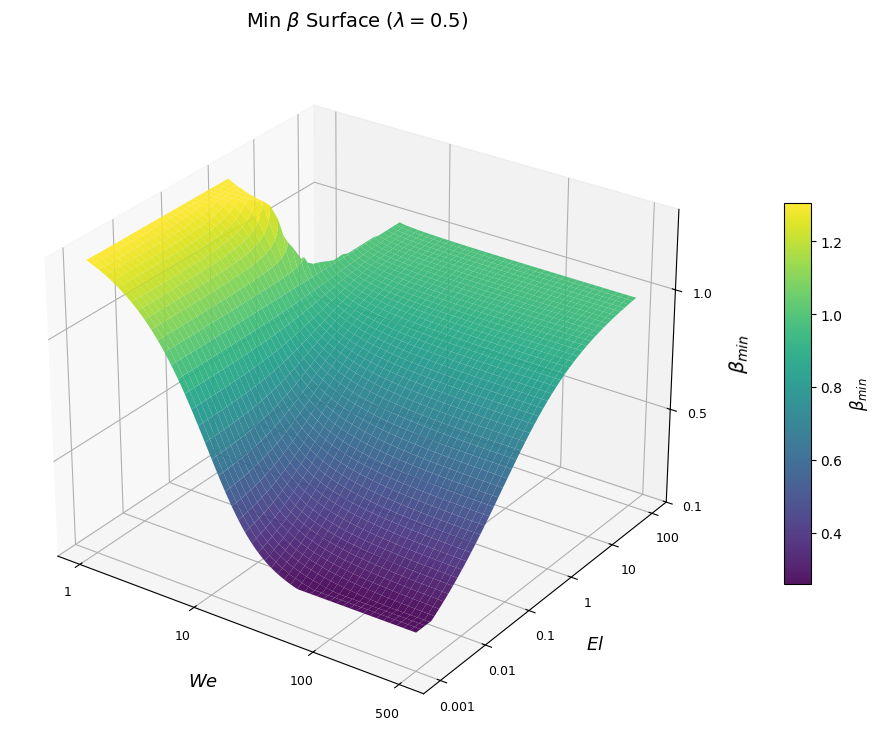

In [2]:
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

# Mask NaN for clean surface
valid = ~np.isnan(min_beta_map)
Z_min = np.where(valid, min_beta_map, np.nan)

# Clip extreme outliers for a readable colour scale
vmin_min = np.nanpercentile(Z_min,  2)
vmax_min = np.nanpercentile(Z_min, 98)
Z_min_clipped = np.clip(Z_min, vmin_min, vmax_min)

surf_min = ax.plot_surface(
    np.log10(WE), np.log10(EL), Z_min_clipped,
    cmap='viridis',
    linewidth=0, antialiased=True,
    alpha=0.92,
    vmin=vmin_min, vmax=vmax_min
)

# Colour bar
cbar_min = fig.colorbar(surf_min, ax=ax, shrink=0.55, aspect=14, pad=0.08)
cbar_min.set_label(r'$\beta_{min}$', fontsize=12)

# Axis tick labels → original (non-log) values
ax.set_xticks(we_ticks);  ax.set_xticklabels(we_labels, fontsize=9)
ax.set_yticks(el_ticks);  ax.set_yticklabels(el_labels, fontsize=9)

# Z-axis (min beta) ticks
z_ticks_min = np.array([0.1, 0.5, 1, 2, 5, 10])
z_ticks_min = z_ticks_min[z_ticks_min <= vmax_min]
if 1 not in z_ticks_min:
    z_ticks_min = np.insert(z_ticks_min, 0, 1)
ax.set_zticks(z_ticks_min)
ax.set_zticklabels([str(round(t, 2)) for t in z_ticks_min], fontsize=9)

ax.set_xlabel(r'$We$',         fontsize=13, labelpad=10)
ax.set_ylabel(r'$El$',         fontsize=13, labelpad=10)
ax.set_zlabel(r'$\beta_{min}$',      fontsize=14, labelpad=8)
ax.set_title(
    r'Min $\beta$ Surface ($λ = $' + f'{LAMBDA})',
    fontsize=14, pad=15
)

ax.view_init(elev=28, azim=-55)
plt.tight_layout()
out_min = "min_beta_surface_We_El.png"
plt.savefig(out_min, dpi=180, bbox_inches='tight')
print(f"Saved → {out_min}")
plt.show()

/tmp/ipykernel_17273/1874113034.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved → max_beta_surface_We_El.png


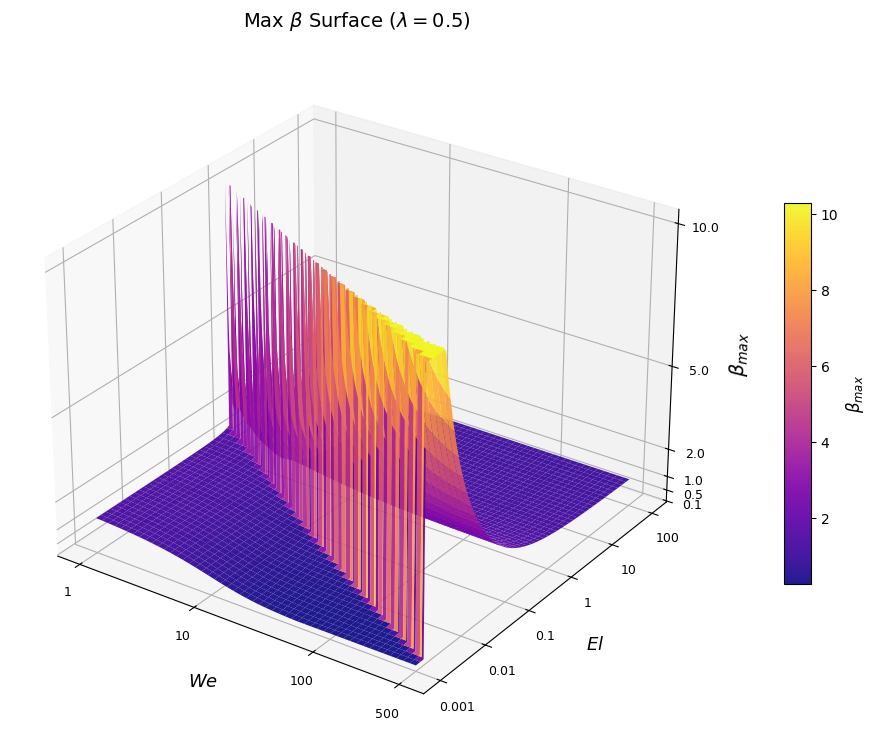

In [3]:
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

# Mask NaN for clean surface
valid = ~np.isnan(max_beta_map)
Z_max = np.where(valid, max_beta_map, np.nan)

# Clip extreme outliers for a readable colour scale
vmin_max = np.nanpercentile(Z_max,  2)
vmax_max = np.nanpercentile(Z_max, 98)
Z_max_clipped = np.clip(Z_max, vmin_max, vmax_max)

surf_max = ax.plot_surface(
    np.log10(WE), np.log10(EL), Z_max_clipped,
    cmap='plasma',
    linewidth=0, antialiased=True,
    alpha=0.92,
    vmin=vmin_max, vmax=vmax_max
)

# Colour bar
cbar_max = fig.colorbar(surf_max, ax=ax, shrink=0.55, aspect=14, pad=0.08)
cbar_max.set_label(r'$\beta_{max}$', fontsize=12)

# Axis tick labels → original (non-log) values
ax.set_xticks(we_ticks);  ax.set_xticklabels(we_labels, fontsize=9)
ax.set_yticks(el_ticks);  ax.set_yticklabels(el_labels, fontsize=9)

# Z-axis (max beta) ticks
z_ticks_max = np.array([0.1, 0.5, 1, 2, 5, 10])
z_ticks_max = z_ticks_max[z_ticks_max <= vmax_max]
if 1 not in z_ticks_max:
    z_ticks_max = np.insert(z_ticks_max, 0, 1)
ax.set_zticks(z_ticks_max)
ax.set_zticklabels([str(round(t, 2)) for t in z_ticks_max], fontsize=9)

ax.set_xlabel(r'$We$',         fontsize=13, labelpad=10)
ax.set_ylabel(r'$El$',         fontsize=13, labelpad=10)
ax.set_zlabel(r'$\beta_{max}$',      fontsize=14, labelpad=8)
ax.set_title(
    r'Max $\beta$ Surface ($λ = $' + f'{LAMBDA})',
    fontsize=14, pad=15
)

ax.view_init(elev=28, azim=-55)
plt.tight_layout()
out_max = "max_beta_surface_We_El.png"
plt.savefig(out_max, dpi=180, bbox_inches='tight')
print(f"Saved → {out_max}")
plt.show()

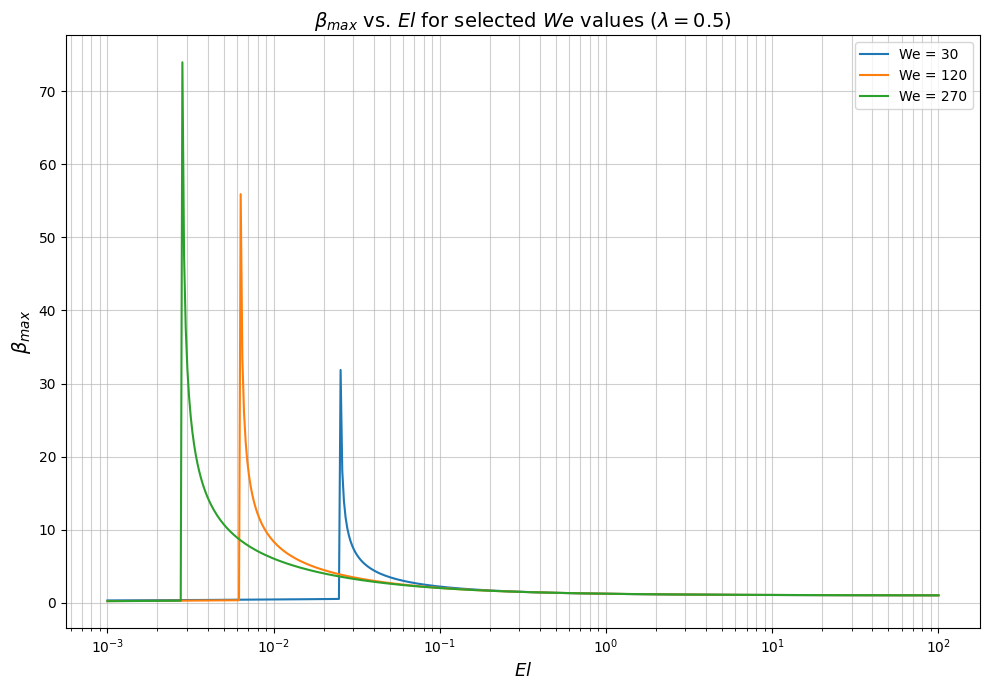

In [4]:
target_we_vals = [30, 120, 270]

plt.figure(figsize=(10, 7))

for we_target in target_we_vals:
    beta_max_for_we = []
    for el_val in El_vals:
        # Recalculate the coefficients for the target We and current El
        denom1_target = 1.0 - 0.75 / (we_target * el_val)
        denom2_target = 2.0 * we_target * el_val - 1.5

        if abs(denom1_target) < 1e-10 or abs(denom2_target) < 1e-10:
            beta_max_for_we.append(np.nan)
            continue

        A_target = (1.5 + 0.5 / el_val * (1.0 - LAMBDA)) / denom1_target
        B_target =  4.0 / denom2_target
        C_target =  0.5 / denom1_target

        coeffs_target = [1, 0, -A_target, B_target, 0, 0, C_target]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            roots_target = np.roots(coeffs_target)

        pos_real_target = [
            r.real for r in roots_target
            if abs(r.imag) < 1e-6 * max(abs(r.real), 1e-12) and r.real > 0
        ]

        if pos_real_target:
            beta_max_for_we.append(max(pos_real_target))
        else:
            beta_max_for_we.append(np.nan)

    plt.plot(El_vals, beta_max_for_we, label=f'We = {we_target}')

plt.xscale('log')
plt.xlabel(r'$El$', fontsize=13)
plt.ylabel(r'$\beta_{max}$', fontsize=14)
plt.title(r'$\beta_{max}$ vs. $El$ for selected $We$ values ($λ = $' + f'{LAMBDA})', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

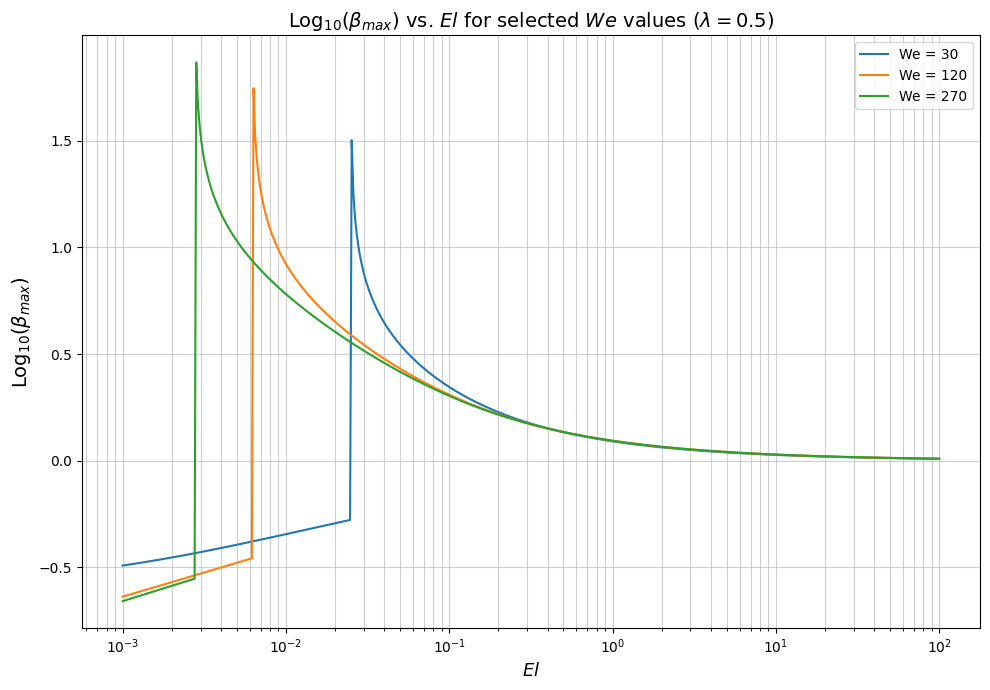

In [6]:
plt.figure(figsize=(10, 7))

for we_target in target_we_vals:
    beta_max_for_we = []
    for el_val in El_vals:
        # Recalculate the coefficients for the target We and current El
        denom1_target = 1.0 - 0.75 / (we_target * el_val)
        denom2_target = 2.0 * we_target * el_val - 1.5

        if abs(denom1_target) < 1e-10 or abs(denom2_target) < 1e-10:
            beta_max_for_we.append(np.nan)
            continue

        A_target = (1.5 + 0.5 / el_val * (1.0 - LAMBDA)) / denom1_target
        B_target =  4.0 / denom2_target
        C_target =  0.5 / denom1_target

        coeffs_target = [1, 0, -A_target, B_target, 0, 0, C_target]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            roots_target = np.roots(coeffs_target)

        pos_real_target = [
            r.real for r in roots_target
            if abs(r.imag) < 1e-6 * max(abs(r.real), 1e-12) and r.real > 0
        ]

        if pos_real_target:
            beta_max_for_we.append(max(pos_real_target))
        else:
            beta_max_for_we.append(np.nan)

    # Plot log10 of beta_max
    plt.plot(El_vals, np.log10(beta_max_for_we), label=f'We = {we_target}')

plt.xscale('log')
plt.xlabel(r'$El$', fontsize=13)
plt.ylabel(r'Log$_{10}(\beta_{max})$', fontsize=14)
plt.title(r'Log$_{10}(\beta_{max})$ vs. $El$ for selected $We$ values ($λ = $' + f'{LAMBDA})', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

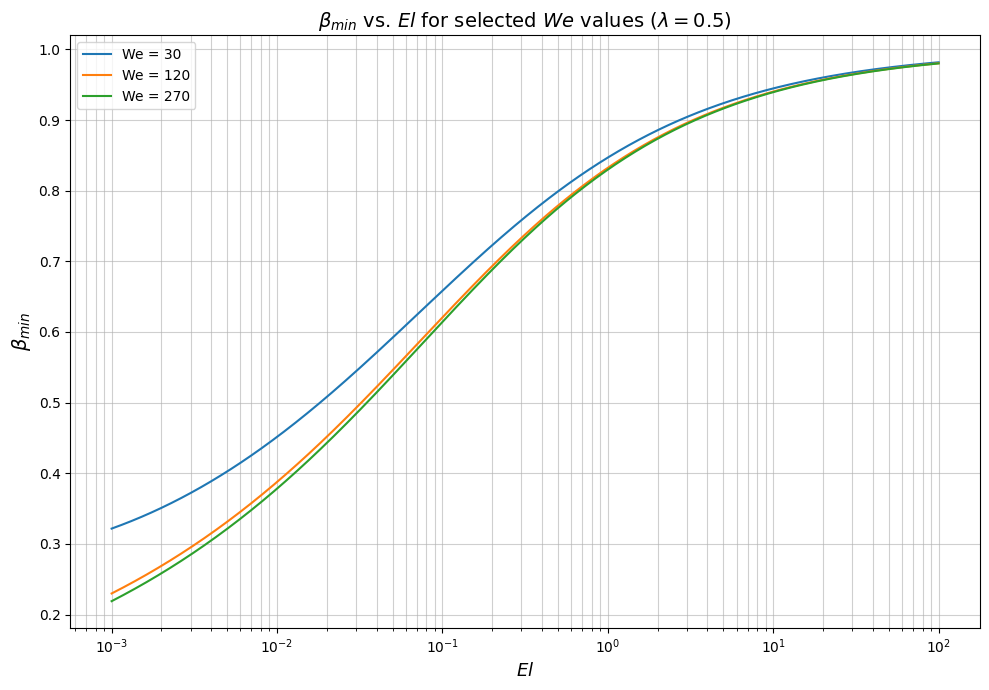

In [5]:
target_we_vals = [30, 120, 270]

plt.figure(figsize=(10, 7))

for we_target in target_we_vals:
    beta_min_for_we = []
    for el_val in El_vals:
        # Recalculate the coefficients for the target We and current El
        denom1_target = 1.0 - 0.75 / (we_target * el_val)
        denom2_target = 2.0 * we_target * el_val - 1.5

        if abs(denom1_target) < 1e-10 or abs(denom2_target) < 1e-10:
            beta_min_for_we.append(np.nan)
            continue

        A_target = (1.5 + 0.5 / el_val * (1.0 - LAMBDA)) / denom1_target
        B_target =  4.0 / denom2_target
        C_target =  0.5 / denom1_target

        coeffs_target = [1, 0, -A_target, B_target, 0, 0, C_target]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            roots_target = np.roots(coeffs_target)

        pos_real_target = [
            r.real for r in roots_target
            if abs(r.imag) < 1e-6 * max(abs(r.real), 1e-12) and r.real > 0
        ]

        if pos_real_target:
            beta_min_for_we.append(min(pos_real_target)) # Changed to min
        else:
            beta_min_for_we.append(np.nan)

    plt.plot(El_vals, beta_min_for_we, label=f'We = {we_target}')

plt.xscale('log')
plt.xlabel(r'$El$', fontsize=13)
plt.ylabel(r'$\beta_{min}$', fontsize=14) # Changed label
plt.title(r'$\beta_{min}$ vs. $El$ for selected $We$ values ($λ = $' + f'{LAMBDA})', fontsize=14) # Changed title
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

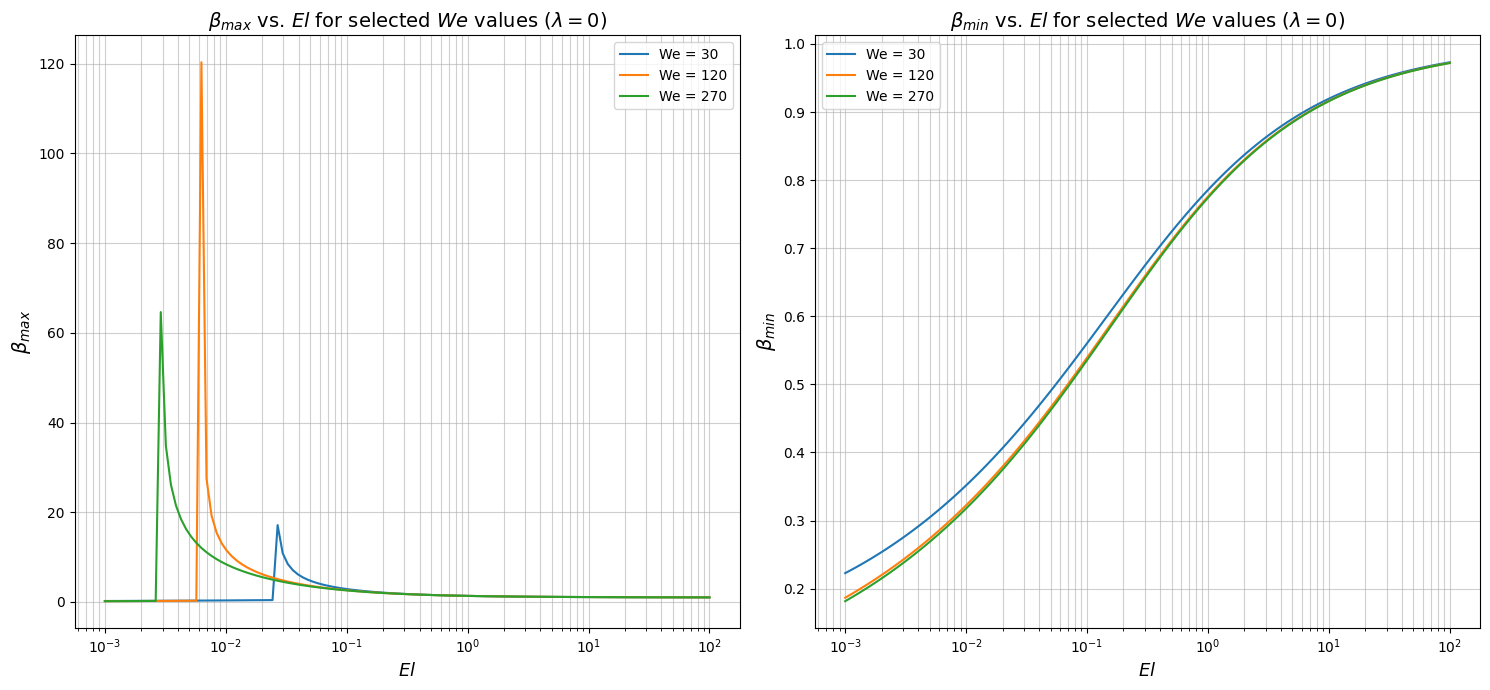

In [ ]:
plt.figure(figsize=(15, 7))

# Subplot for beta_max
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
for we_target in target_we_vals:
    beta_max_for_we_plot = []
    for el_val in El_vals:
        denom1_target = 1.0 - 0.75 / (we_target * el_val)
        denom2_target = 2.0 * we_target * el_val - 1.5

        if abs(denom1_target) < 1e-10 or abs(denom2_target) < 1e-10:
            beta_max_for_we_plot.append(np.nan)
            continue

        A_target = (1.5 + 0.5 / el_val * (1.0 - LAMBDA)) / denom1_target
        B_target =  4.0 / denom2_target
        C_target =  0.5 / denom1_target

        coeffs_target = [1, 0, -A_target, B_target, 0, 0, C_target]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            roots_target = np.roots(coeffs_target)

        pos_real_target = [
            r.real for r in roots_target
            if abs(r.imag) < 1e-6 * max(abs(r.real), 1e-12) and r.real > 0
        ]

        if pos_real_target:
            beta_max_for_we_plot.append(max(pos_real_target))
        else:
            beta_max_for_we_plot.append(np.nan)

    plt.plot(El_vals, beta_max_for_we_plot, label=f'We = {we_target}')

plt.xscale('log')
plt.xlabel(r'$El$', fontsize=13)
plt.ylabel(r'$\beta_{max}$', fontsize=14)
plt.title(r'$\beta_{max}$ vs. $El$ for selected $We$ values ($λ = $' + f'{LAMBDA})', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)

# Subplot for beta_min
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
for we_target in target_we_vals:
    beta_min_for_we_plot = []
    for el_val in El_vals:
        denom1_target = 1.0 - 0.75 / (we_target * el_val)
        denom2_target = 2.0 * we_target * el_val - 1.5

        if abs(denom1_target) < 1e-10 or abs(denom2_target) < 1e-10:
            beta_min_for_we_plot.append(np.nan)
            continue

        A_target = (1.5 + 0.5 / el_val * (1.0 - LAMBDA)) / denom1_target
        B_target =  4.0 / denom2_target
        C_target =  0.5 / denom1_target

        coeffs_target = [1, 0, -A_target, B_target, 0, 0, C_target]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            roots_target = np.roots(coeffs_target)

        pos_real_target = [
            r.real for r in roots_target
            if abs(r.imag) < 1e-6 * max(abs(r.real), 1e-12) and r.real > 0
        ]

        if pos_real_target:
            beta_min_for_we_plot.append(min(pos_real_target))
        else:
            beta_min_for_we_plot.append(np.nan)

    plt.plot(El_vals, beta_min_for_we_plot, label=f'We = {we_target}')

plt.xscale('log')
plt.xlabel(r'$El$', fontsize=13)
plt.ylabel(r'$\beta_{min}$', fontsize=14)
plt.title(r'$\beta_{min}$ vs. $El$ for selected $We$ values ($λ = $' + f'{LAMBDA})', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)

plt.tight_layout()
plt.show()

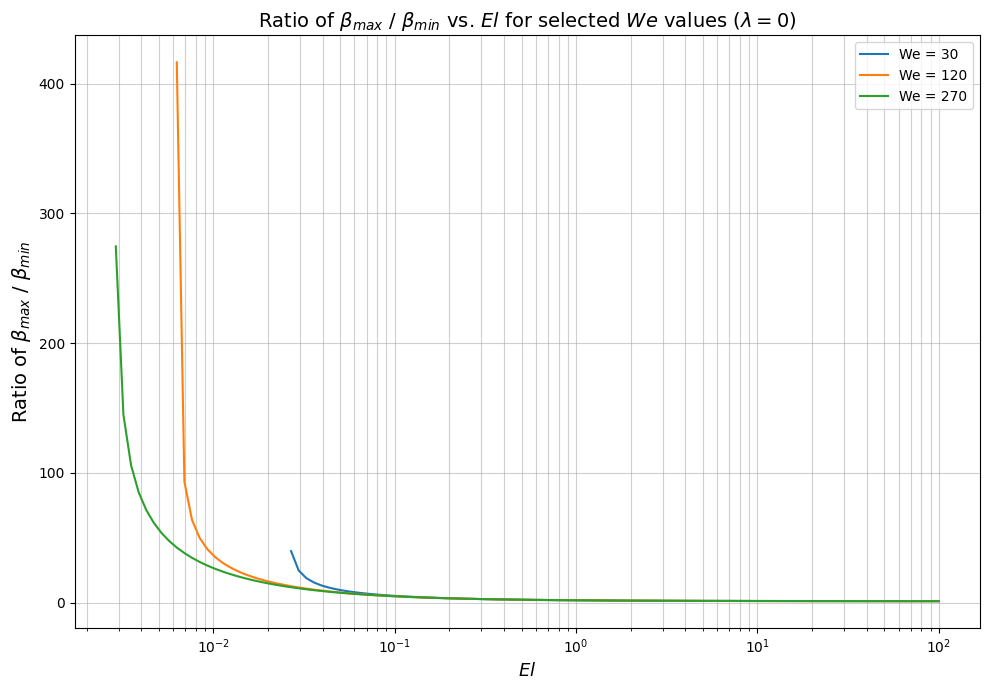

In [ ]:
plt.figure(figsize=(10, 7))

for we_target in target_we_vals:
    beta_ratio_for_we = []
    for el_val in El_vals:
        denom1_target = 1.0 - 0.75 / (we_target * el_val)
        denom2_target = 2.0 * we_target * el_val - 1.5

        if abs(denom1_target) < 1e-10 or abs(denom2_target) < 1e-10:
            beta_ratio_for_we.append(np.nan)
            continue

        A_target = (1.5 + 0.5 / el_val * (1.0 - LAMBDA)) / denom1_target
        B_target =  4.0 / denom2_target
        C_target =  0.5 / denom1_target

        coeffs_target = [1, 0, -A_target, B_target, 0, 0, C_target]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            roots_target = np.roots(coeffs_target)

        pos_real_target = [
            r.real for r in roots_target
            if abs(r.imag) < 1e-6 * max(abs(r.real), 1e-12) and r.real > 0
        ]

        if len(pos_real_target) >= 2: # Need at least two roots for a ratio
            min_beta = min(pos_real_target)
            max_beta = max(pos_real_target)
            beta_ratio_for_we.append(max_beta / min_beta)
        else:
            beta_ratio_for_we.append(np.nan)

    plt.plot(El_vals, beta_ratio_for_we, label=f'We = {we_target}')

plt.xscale('log')
plt.xlabel(r'$El$', fontsize=13)
plt.ylabel(r'Ratio of $\beta_{max}$ / $\beta_{min}$', fontsize=14)
plt.title(r'Ratio of $\beta_{max}$ / $\beta_{min}$ vs. $El$ for selected $We$ values ($λ = $' + f'{LAMBDA})', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

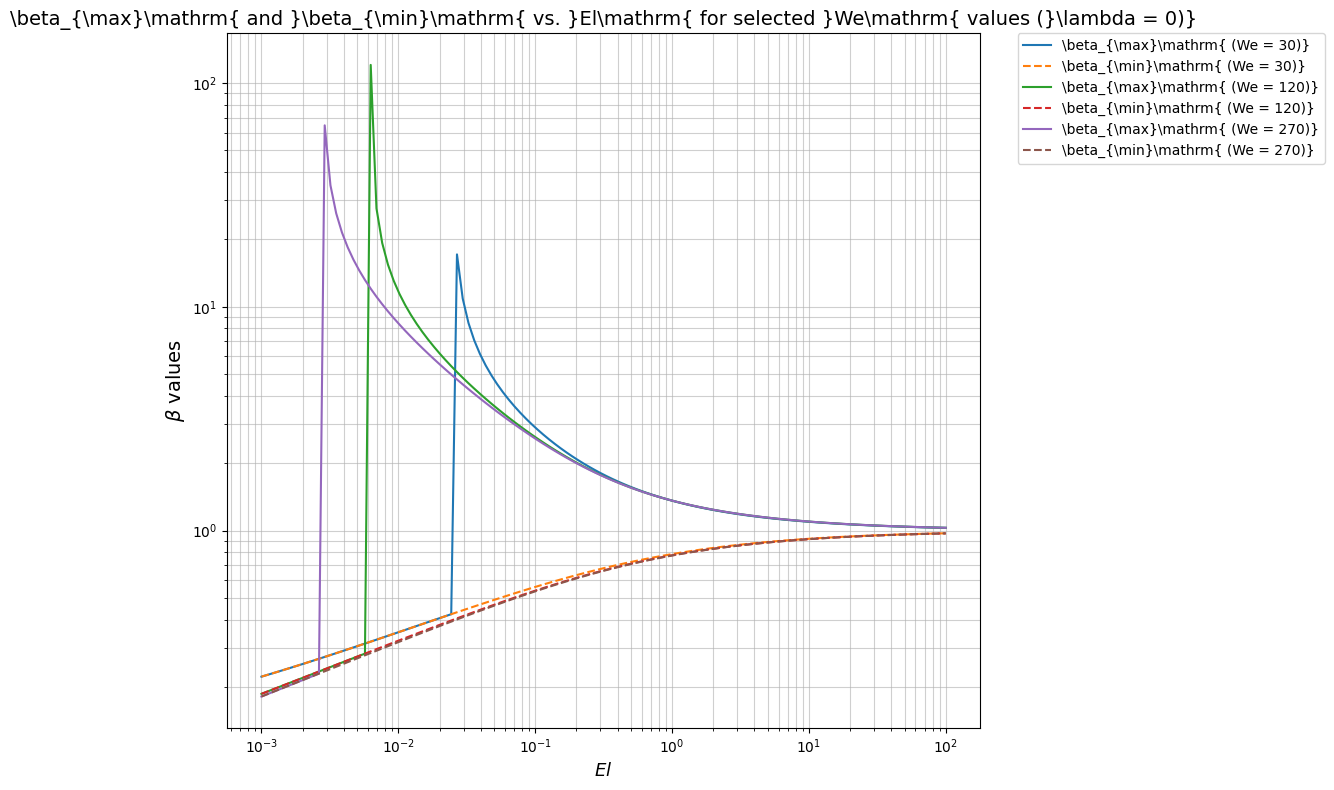

In [ ]:
plt.figure(figsize=(12, 8))

for we_target in target_we_vals:
    beta_max_for_we_plot = []
    beta_min_for_we_plot = []

    for el_val in El_vals:
        denom1_target = 1.0 - 0.75 / (we_target * el_val)
        denom2_target = 2.0 * we_target * el_val - 1.5

        if abs(denom1_target) < 1e-10 or abs(denom2_target) < 1e-10:
            beta_max_for_we_plot.append(np.nan)
            beta_min_for_we_plot.append(np.nan)
            continue

        A_target = (1.5 + 0.5 / el_val * (1.0 - LAMBDA)) / denom1_target
        B_target =  4.0 / denom2_target
        C_target =  0.5 / denom1_target

        coeffs_target = [1, 0, -A_target, B_target, 0, 0, C_target]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            roots_target = np.roots(coeffs_target)

        pos_real_target = [
            r.real for r in roots_target
            if abs(r.imag) < 1e-6 * max(abs(r.real), 1e-12) and r.real > 0
        ]

        if pos_real_target:
            beta_max_for_we_plot.append(max(pos_real_target))
            beta_min_for_we_plot.append(min(pos_real_target))
        else:
            beta_max_for_we_plot.append(np.nan)
            beta_min_for_we_plot.append(np.nan)

    plt.plot(El_vals, beta_max_for_we_plot, label=f'\\beta_{{\\max}}\\mathrm{{ (We = {we_target})}}', linestyle='-', marker='')
    plt.plot(El_vals, beta_min_for_we_plot, label=f'\\beta_{{\\min}}\\mathrm{{ (We = {we_target})}}', linestyle='--', marker='')

plt.xscale('log')
plt.yscale('log') # Added log scale to y-axis
plt.xlabel(r'$El$', fontsize=13)
plt.ylabel(r'$\beta$ values', fontsize=14)
plt.title(f'\\beta_{{\\max}}\\mathrm{{ and }}\\beta_{{\\min}}\\mathrm{{ vs. }}El\\mathrm{{ for selected }}We\\mathrm{{ values (}}\\lambda = {LAMBDA})}}', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
we_target = 10
el_target = 100

# Using the same LAMBDA from the original cell
# LAMBDA = 0.1

# Recalculate the coefficients for the target We and El
denom1_target = 1.0 - 0.75 / (we_target * el_target)
denom2_target = 2.0 * we_target * el_target - 1.5

if abs(denom1_target) < 1e-10 or abs(denom2_target) < 1e-10:
    print(f"Singular point for We={we_target}, El={el_target}")
else:
    A_target = (1.5 + 0.5 / el_target * (1.0 - LAMBDA)) / denom1_target
    B_target =  4.0 / denom2_target
    C_target =  0.5 / denom1_target

    coeffs_target = [1, 0, -A_target, B_target, 0, 0, C_target]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        roots_target = np.roots(coeffs_target)

    print(f"All roots for We={we_target}, El={el_target}:")
    for root in roots_target:
        print(f"  {root}")

    pos_real_target = [
        r.real for r in roots_target
        if abs(r.imag) < 1e-6 * max(abs(r.real), 1e-12) and r.real > 0
    ]

    if pos_real_target:
        beta_at_target = min(pos_real_target)
        print(f"\nSmallest positive real beta at We={we_target}, El={el_target}: {beta_at_target}")
    else:
        print(f"\nNo positive real roots found for We={we_target}, El={el_target}")

All roots for We=10, El=100:
  (1.0240370946156159+0j)
  (0.9774498636837632+0j)
  (-1.0357425115405627+0j)
  (-0.9661882498787894+0j)
  (0.00022190155998648474+0.7067829038071457j)
  (0.00022190155998648474-0.7067829038071457j)

Smallest positive real beta at We=10, El=100: 0.9774498636837632
